In [ ]:
from morphapi.api.allenmorphology import AllenMorphology


am = AllenMorphology()


# Select mouse neurons in the primary visual cortex
neurons = am.neurons.loc[
    (am.neurons.species == "Mus musculus")
    & (am.neurons.structure_area_abbrev == "VISp")
]

# Download some of these neurons
neurons = am.download_neurons(neurons[:5].id.values)

In [4]:
from pathlib import Path
from brainrender._io import load_mesh_from_file
from myterial import orange
from rich import print
from brainglobe_atlasapi import BrainGlobeAtlas
from brainrender import Scene
import brainrender
from brainrender.actors import Points, Line
import numpy as np

bg_atlas = BrainGlobeAtlas("allen_mouse_100um", check_latest=False)
bg_atlas.lookup_df.acronym.values
region = 'CA'
obj_file = str(bg_atlas.meshfile_from_structure(region))
print(obj_file)

mesh = load_mesh_from_file(obj_file, alpha=0.2, color="green")


C:\Users\jhahn\.brainglobe\allen_mouse_100um_v1.2\meshes\375.obj

In [ ]:
from vedo import *
from vtk.util import numpy_support

cam = dict(
    position=(3,3,3),
    focal_point=(0.5, 0.5, 0.5),
    viewup=(0,1,0),
    distance=10.562,
    clipping_range=(2.53177, 4.93023),
)

mesh = load_obj('output/piece_3.obj')[0].color('b')

_data = mesh.dataset.GetPoints().GetData()
_data_np = numpy_support.vtk_to_numpy(_data)

max_y = np.max(numpy_support.vtk_to_numpy(mesh.dataset.GetPoints().GetData()), axis=0)[1]
_data_w = []
for w in _data_np:
    if w[1] == max_y:
        _data_w.append(w)
_data_w = np.array(_data_w)
_data_w.shape     
#plt = Plotter(size=(600,400))
#plt.show(mesh.box().color('g').alpha(0.4), axes=1, title="matplotlib colors", interactive=False, camera=cam)
#plt.screenshot(filename=f'output/brain1.png')
#plt.close()

(10304, 3)

In [3]:
mesh.vertices

array([[0.8496538 , 1.3647234 , 0.6425917 ],
       [0.8496546 , 1.3647234 , 0.64258945],
       [0.8496563 , 1.3647215 , 0.6425903 ],
       ...,
       [0.84988225, 1.3647234 , 0.6430373 ],
       [0.8498589 , 1.3647234 , 0.6430507 ],
       [0.8498355 , 1.3647234 , 0.6430641 ]], dtype=float32)

In [2]:
np.repeat([1.3647234],2)

array([1.3647234, 1.3647234])

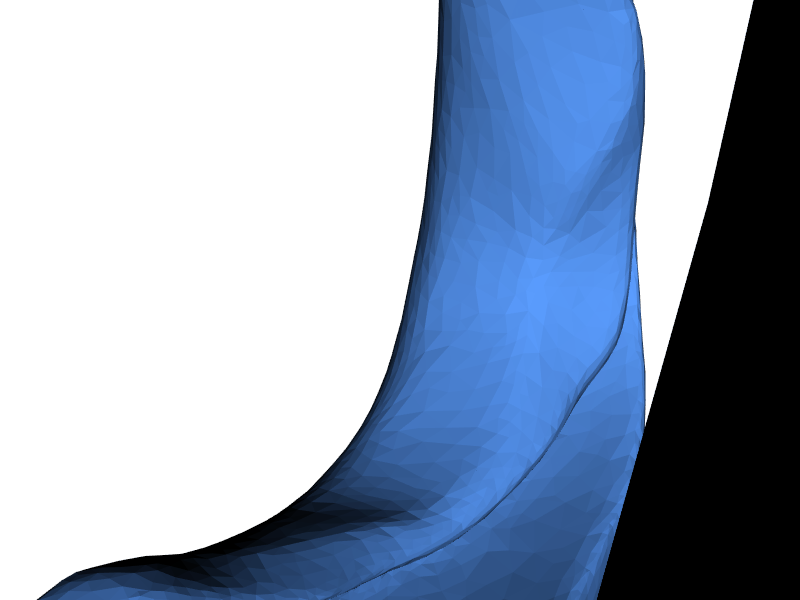

In [10]:
from vedo import *
meshes = load_obj('C:/workkspace/brainrender/resources/samples/375.obj')
show(meshes[0].tetralize().tomesh(fill=False))


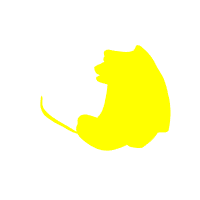

In [3]:
from vedo import *
m = load_obj('C:/workkspace/brainrender/resources/samples/1089.obj')[0]
#show(meshes[0].tetralize().tomesh(fill=False))

bb_ids = m.boundaries(non_manifold_edges=True, boundary_edges=True, return_cell_ids=True)
m=m.delete_cells(bb_ids).clean()
m=m.fill_holes(size=1000)
m

In [4]:
from utils import slice_util
slice_util.combine_obj_files([str('resources/samples').replace("\\",'/')],'resources/1089_8.obj')

resources/samples/1089.obj
(14773, 3)
resources/samples/8.obj
(87732, 3)
resources/samples/1089.obj
(14773, 3)
resources/samples/8.obj
(87732, 3)


In [1]:
from utils import slice_util
slice_util.combine_obj_files([str('C:/Users/jhahn/.brainglobe/allen_mouse_100um_v1.2/meshes').replace("\\",'/')],'resources')

C:/Users/jhahn/.brainglobe/allen_mouse_100um_v1.2/meshes/1.obj
(229, 3)
C:/Users/jhahn/.brainglobe/allen_mouse_100um_v1.2/meshes/2.obj
(777, 3)
C:/Users/jhahn/.brainglobe/allen_mouse_100um_v1.2/meshes/4.obj
(2456, 3)
C:/Users/jhahn/.brainglobe/allen_mouse_100um_v1.2/meshes/6.obj
(3483, 3)
C:/Users/jhahn/.brainglobe/allen_mouse_100um_v1.2/meshes/7.obj
(1021, 3)
C:/Users/jhahn/.brainglobe/allen_mouse_100um_v1.2/meshes/8.obj
(87732, 3)
C:/Users/jhahn/.brainglobe/allen_mouse_100um_v1.2/meshes/9.obj
(457, 3)
C:/Users/jhahn/.brainglobe/allen_mouse_100um_v1.2/meshes/10.obj
(2452, 3)
C:/Users/jhahn/.brainglobe/allen_mouse_100um_v1.2/meshes/12.obj
(158, 3)
C:/Users/jhahn/.brainglobe/allen_mouse_100um_v1.2/meshes/15.obj
(377, 3)
C:/Users/jhahn/.brainglobe/allen_mouse_100um_v1.2/meshes/17.obj
(2266, 3)
C:/Users/jhahn/.brainglobe/allen_mouse_100um_v1.2/meshes/19.obj
(424, 3)
C:/Users/jhahn/.brainglobe/allen_mouse_100um_v1.2/meshes/20.obj
(2363, 3)
C:/Users/jhahn/.brainglobe/allen_mouse_100um_v1.2/

[[array([[7447.74, 6462.68, 4408.32],
         [7405.15, 6482.94, 4412.79],
         [7430.69, 6497.42, 4406.83],
         [7500.29, 6494.18, 4433.7 ],
         [7402.85, 6528.99, 4417.71],
         [7451.77, 6553.4 , 4431.13],
         [7390.55, 6460.17, 4449.29],
         [7442.68, 6441.62, 4451.67],
         [7503.95, 6451.74, 4460.17],
         [7378.26, 6526.98, 4448.07],
         [7533.18, 6544.89, 4463.18],
         [7395.16, 6595.71, 4460.24],
         [7514.42, 6597.57, 4477.91],
         [7418.76, 6433.02, 4478.1 ],
         [7563.64, 6470.48, 4492.67],
         [7370.47, 6489.05, 4482.27],
         [7599.33, 6517.94, 4523.24],
         [7361.08, 6614.55, 4512.46],
         [7444.4 , 6654.41, 4502.35],
         [7517.64, 6426.61, 4513.24],
         [7471.01, 6429.85, 4533.42],
         [7360.29, 6551.18, 4517.01],
         [7588.45, 6615.73, 4567.93],
         [7373.46, 6648.06, 4505.67],
         [7498.42, 6713.26, 4571.17],
         [7539.15, 6672.25, 4567.26],
         [73

In [4]:
neurons[0].create_mesh()


({'soma': <vedo.mesh.Mesh at 0x21945723250>,
  'basal_dendrites': <vedo.mesh.Mesh at 0x219457513d0>,
  'apical_dendrites': <vedo.mesh.Mesh at 0x21945733dd0>,
  'axon': None},
 <vedo.mesh.Mesh at 0x21945751dd0>)

In [2]:
from vedo import *
import random
from matplotlib import colormaps
from vedo.colors import colors
from operator import itemgetter
import os
from vtk.util import numpy_support


In [3]:
meshes = load_obj('output/meshes.obj')



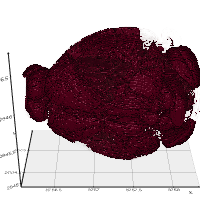

In [4]:
_vol = meshes[0].normalize().binarize()
_vol

In [9]:
_vol_norm = _vol.clone().isosurface(4, flying_edges=False).pos(0,0,0).color('yellow5', 0.5)